<div style="direction:rtl;text-align:right;font-family:Tahoma">
اگر روی گوگل کولب اجرا میکنید این خطوط را از حالت کامنت خارج نمائید.
</div>

In [1]:
!wget https://raw.githubusercontent.com/Alireza-Akhavan/SRU-deeplearning-workshop/master/dataset.py
!wget https://github.com/Alireza-Akhavan/SRU-deeplearning-workshop/raw/master/dataset/Data_hoda_full.mat -P dataset

--2025-12-25 12:45:46--  https://raw.githubusercontent.com/Alireza-Akhavan/SRU-deeplearning-workshop/master/dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 917 [text/plain]
Saving to: ‘dataset.py.1’

dataset.py.1        100%[===================>]     917  --.-KB/s    in 0s      

2025-12-25 12:45:46 (65.9 MB/s) - ‘dataset.py.1’ saved [917/917]

--2025-12-25 12:45:47--  https://github.com/Alireza-Akhavan/SRU-deeplearning-workshop/raw/master/dataset/Data_hoda_full.mat
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/Alireza-Akhavan/deeplearning-tensorflow2-notebooks/raw/master/dataset/Data_

In [2]:
# 1. Import libraries and modules
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
import numpy as np
from dataset import load_hoda
import matplotlib.pyplot as plt

In [3]:

# Load pre-shuffled HODA data into train and test sets
X_train, y_train, X_test, y_test = load_hoda(
                                            training_sample_size=3500,
                                            test_sample_size=400,size=28)

In [4]:
# Preprocess input data
'''standard our data values to the range [-1, 1]'''
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = (X_train - 127.5) / 127.5
X_test = (X_test - 127.5) / 127.5

In [5]:
# Reshape to original image shape (n x 784)  ==> (n x 28 x 28 x 1)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [6]:
nonlinear_bn = Sequential([keras.Input(shape=(28,28,1)),
                      layers.Conv2D(32, (3, 3), activation='relu'),
                      BatchNormalization(),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3), activation='relu'),
                      BatchNormalization(),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3), activation='relu'),
                      BatchNormalization(),
                      layers.Flatten(),
                      layers.Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(0.5),
                      layers.Dense(10, activation='softmax')])

In [7]:
# 5. Define model architecture
bn_nonlinear = Sequential([keras.Input(shape=(28,28,1)),
                      layers.Conv2D(32, (3, 3)),
                      BatchNormalization(),
                      layers.Activation('relu'),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3)),
                      BatchNormalization(),
                      layers.Activation('relu'),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3)),
                      BatchNormalization(),
                      layers.Activation('relu'),
                      layers.Flatten(),
                      layers.Dense(64),
                      BatchNormalization(),
                      layers.Activation('relu'),
                      Dropout(0.5),
                      layers.Dense(10, activation='softmax')])

In [8]:
with_no_bn = Sequential([keras.Input(shape=(28,28,1)),
                      layers.Conv2D(32, (3, 3), activation='relu'),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3), activation='relu'),
                      layers.MaxPooling2D((2, 2)),
                      layers.Conv2D(64, (3, 3), activation='relu'),
                      layers.Flatten(),
                      layers.Dense(64, activation='relu'),
                      Dropout(0.5),
                      layers.Dense(10, activation='softmax')])

In [9]:
# 6. Compile model
nonlinear_bn.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['sparse_categorical_accuracy'])


# 7. Fit model on training data
history_nonlinear_bn = nonlinear_bn.fit(X_train, y_train,
          epochs=100, batch_size=256, validation_split=0.2)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 594ms/step - loss: 2.4168 - sparse_categorical_accuracy: 0.3285 - val_loss: 2.0198 - val_sparse_categorical_accuracy: 0.7271
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6268 - sparse_categorical_accuracy: 0.8024 - val_loss: 1.8025 - val_sparse_categorical_accuracy: 0.8443
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4302 - sparse_categorical_accuracy: 0.8682 - val_loss: 1.7619 - val_sparse_categorical_accuracy: 0.6343
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3189 - sparse_categorical_accuracy: 0.9087 - val_loss: 1.8165 - val_sparse_categorical_accuracy: 0.3700
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2258 - sparse_categorical_accuracy: 0.9404 - val_loss: 1.8587 - val_sparse_categorical_accuracy: 0.2900
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1797 - sparse_categorical_accuracy: 0.9603 - val_loss: 1.9000 - val_sparse_categorical_accuracy: 0.2429
Ep

In [10]:
# 6. Compile model
bn_nonlinear.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['sparse_categorical_accuracy'])


# 7. Fit model on training data
history_bn_nonlinear = bn_nonlinear.fit(X_train, y_train,
          epochs=100, batch_size=256, validation_split=0.2)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 459ms/step - loss: 2.0254 - sparse_categorical_accuracy: 0.3455 - val_loss: 2.0200 - val_sparse_categorical_accuracy: 0.7214
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7726 - sparse_categorical_accuracy: 0.7913 - val_loss: 1.7852 - val_sparse_categorical_accuracy: 0.8500
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5596 - sparse_categorical_accuracy: 0.8697 - val_loss: 1.6876 - val_sparse_categorical_accuracy: 0.7329
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4428 - sparse_categorical_accuracy: 0.9047 - val_loss: 1.6942 - val_sparse_categorical_accuracy: 0.4757
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3508 - sparse_categorical_accuracy: 0.9317 - val_loss: 1.7279 - val_sparse_categorical_accuracy: 0.3543
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2854 - sparse_categorical_accuracy: 0.9456 - val_loss: 1.7866 - val_sparse_categorical_accuracy: 0.3014
Ep

In [11]:
# 6. Compile model
with_no_bn.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['sparse_categorical_accuracy'])


# 7. Fit model on training data
history_no_bn = with_no_bn.fit(X_train, y_train,
          epochs=100, batch_size=256, validation_split=0.2)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - loss: 2.1210 - sparse_categorical_accuracy: 0.2380 - val_loss: 1.2371 - val_sparse_categorical_accuracy: 0.6371
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.2840 - sparse_categorical_accuracy: 0.5454 - val_loss: 0.6486 - val_sparse_categorical_accuracy: 0.8214
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8311 - sparse_categorical_accuracy: 0.6974 - val_loss: 0.4698 - val_sparse_categorical_accuracy: 0.8471
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6438 - sparse_categorical_accuracy: 0.7811 - val_loss: 0.3787 - val_sparse_categorical_accuracy: 0.8800
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5415 - sparse_categorical_accuracy: 0.8106 - val_loss: 0.2919 - val_sparse_categorical_accuracy: 0.8971
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4477 - sparse_categorical_accuracy: 0.8586 - val_loss: 0.2624 - val_sparse_categorical_accuracy: 0.9086
Epo

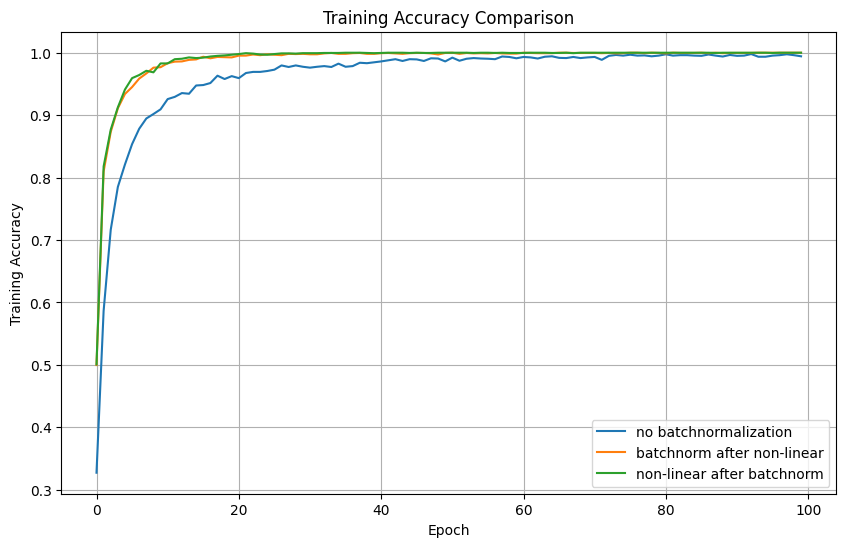

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Training accuracy
plt.plot(history_no_bn.history['sparse_categorical_accuracy'],
         label='no batchnormalization')

plt.plot(history_bn_nonlinear.history['sparse_categorical_accuracy'],
         label='batchnorm after non-linear')

plt.plot(history_nonlinear_bn.history['sparse_categorical_accuracy'],
         label='non-linear after batchnorm')

plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()


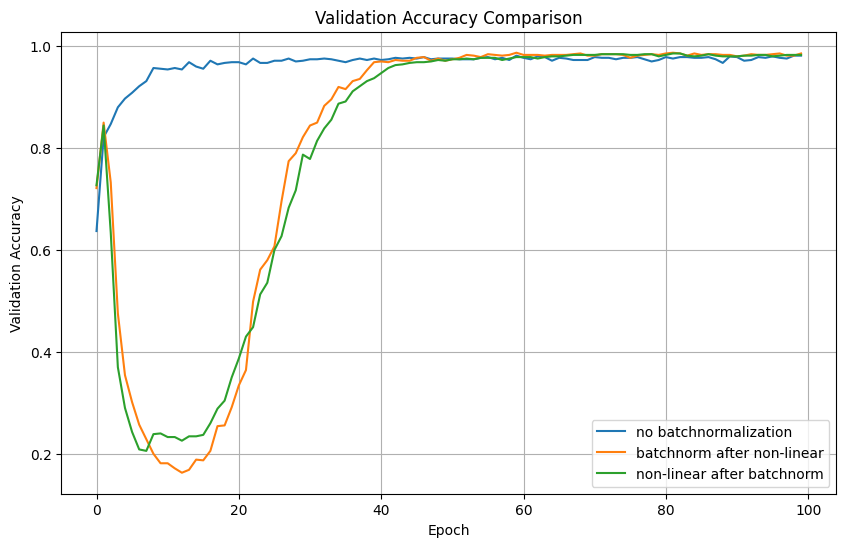

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Training accuracy
plt.plot(history_no_bn.history['val_sparse_categorical_accuracy'],
         label='no batchnormalization')

plt.plot(history_bn_nonlinear.history['val_sparse_categorical_accuracy'],
         label='batchnorm after non-linear')

plt.plot(history_nonlinear_bn.history['val_sparse_categorical_accuracy'],
         label='non-linear after batchnorm')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()
